In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import statsmodels.api as sm
from scipy.stats import norm

df = pd.read_parquet("../data/final_filtered.parquet")
df = df[(df.wage_ratio < 2)&(df.wage_ratio > 0.5)] #filter suspicious values
df["log_ratio"] = np.log(df["wage_ratio"])
df = df[df.log_ratio.notnull()]

df = df[
    df["EMPLOYER_NAME_CLEAN"].map(
        df["EMPLOYER_NAME_CLEAN"].value_counts()
    ) >= 1000
]

level_map = {"I":0,"II":1,"III":2,"IV":3}
df["level_num"] = df["WAGE_LEVEL_CLEAN"].map(level_map)
X = pd.get_dummies(df["EMPLOYER_NAME_CLEAN"], drop_first=True)
X["level"] = df["level_num"]
X["intercept"] = 1

X = X.astype(float).values
y = df["log_ratio"].astype(float).values

# initialize
beta = np.zeros(X.shape[1])
sigma = 1.0

for iteration in range(10):

    mu = X @ beta

    y_star = y.copy()

    # E-step: handle censored points
    censored = (y < 1e-6)

    lambda_term = norm.pdf(mu[censored] / sigma) / (
        1 - norm.cdf(mu[censored] / sigma)
    )

    y_star[censored] = mu[censored] - sigma * lambda_term

    # M-step: regression
    beta = np.linalg.lstsq(X, y_star, rcond=None)[0]

    # update sigma
    residuals = y_star - X @ beta
    sigma = np.sqrt(np.mean(residuals**2))

    print(f"iter {iteration}: sigma={sigma:.4f}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


iter 0: sigma=0.2790
iter 1: sigma=0.1820
iter 2: sigma=0.1637
iter 3: sigma=0.1586
iter 4: sigma=0.1560
iter 5: sigma=0.1542
iter 6: sigma=0.1527
iter 7: sigma=0.1515
iter 8: sigma=0.1505
iter 9: sigma=0.1496


grandison management                -1.070840
cognizant technology solutions us   -0.620654
deloitte touche llp                 -0.593556
hcl global systems                  -0.566035
wipro                               -0.474094
deloitte tax llp                    -0.471530
innova solutions                    -0.365296
netflix                             -0.360669
servicenow                          -0.326877
birlasoft                           -0.303683
tek leaders                         -0.295772
erp analysts                        -0.294526
marlabs                             -0.290878
tekorg                              -0.287013
tech mahindra americas              -0.285299
slk america                         -0.282391
skilltune technologies              -0.278929
intraedge                           -0.268665
sapphire software solutions         -0.267942
salesforce com                      -0.262151
dtype: float64
goldman sachs                                0.002971
kforce     

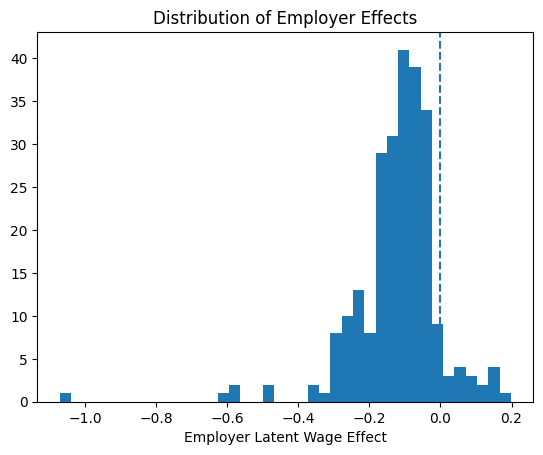

In [7]:
X_df = pd.get_dummies(df["EMPLOYER_NAME_CLEAN"], drop_first=True)
X_df["level"] = df["level_num"]
X_df["intercept"] = 1

columns = X_df.columns

beta_series = pd.Series(beta, index=columns)  # columns = your X column names
intercept = beta_series["intercept"]
level_effect = beta_series["level"]

employer_effects = beta_series.drop(["intercept", "level"])

emp_rank = employer_effects.sort_values()

print(emp_rank.head(20))   # most "low-wage"
print(emp_rank.tail(20))   # highest-paying

plt.hist(employer_effects, bins=40)
plt.axvline(0, linestyle="--")

plt.xlabel("Employer Latent Wage Effect")
plt.title("Distribution of Employer Effects")

plt.show()



In [ ]:
combined = pd.read_csv("combined.csv")

emp_compare = pd.DataFrame({
    "tobit_effect": employer_effects
}).join(combined)

plt.scatter(
    emp_compare["tobit_effect"],
    emp_compare["low_level_prob"]
)
plt.xlabel("Tobit Effect")
plt.ylabel("Low-Level Probability")
plt.show()

threshold = employer_effects.quantile(0.1)

suspicious = employer_effects[employer_effects <= threshold]

print(suspicious)

print("Effect of level:", level_effect)

mu = X @ beta

plt.scatter(mu, y, alpha=0.3)
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.show()

,EMPLOYER_NAME_CLEAN,I,II,III,IV,low_level_prob,low_level_excess,low_mean,low_lower,low_upper,theta_mean
0,abbvie,0.050652,0.384196,0.305797,0.259354,0.434849,-0.120649,0.434849,0.347434,0.529198,0.024538
1,accenture llp,0.037714,0.310553,0.393898,0.257836,0.348266,-0.207232,0.348266,0.274499,0.431484,0.026388
2,adobe,0.050946,0.316453,0.217804,0.414797,0.367399,-0.188099,0.367399,0.273921,0.471145,0.446058
3,adp technology services,0.032688,0.237153,0.543281,0.186878,0.269841,-0.285657,0.269841,0.210912,0.334898,0.024213
4,advanced micro devices,0.111419,0.284151,0.311826,0.292603,0.395570,-0.159928,0.395570,0.312841,0.474953,0.028078
...,...,...,...,...,...,...,...,...,...,...,...
244,workday,0.020456,0.896029,0.032517,0.050999,0.916484,0.360987,0.916484,0.858809,0.957244,0.024647
245,yale university,0.697619,0.130144,0.151334,0.020903,0.827762,0.272265,0.827762,0.774974,0.875270,0.098807
246,zillow,0.083359,0.204060,0.295648,0.416934,0.287418,-0.268080,0.287418,0.203418,0.368646,0.059388
247,zoox,0.052479,0.279120,0.363130,0.305272,0.331599,-0.223899,0.331599,0.250288,0.416014,0.025890


Correlation (Tobit vs low-level): -0.1183381950304243
Correlation (Tobit vs bunching): -0.7639630013616627


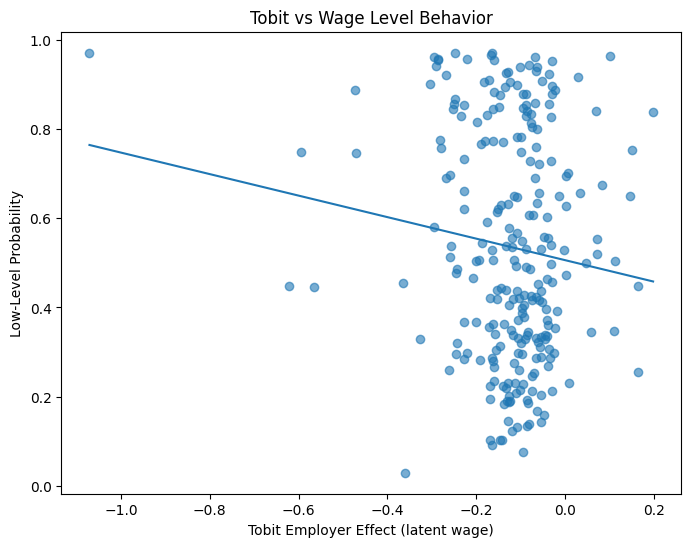

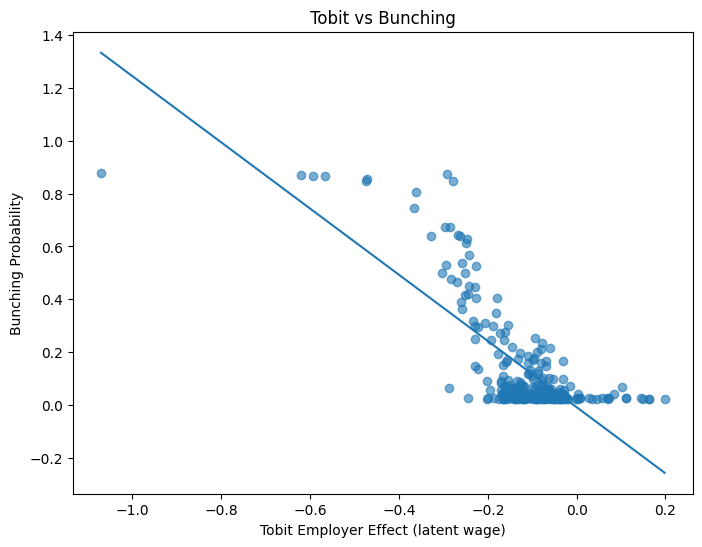

                            OLS Regression Results                            
Dep. Variable:         low_level_prob   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.494
Date:                Tue, 28 Apr 2026   Prob (F-statistic):             0.0628
Time:                        15:43:50   Log-Likelihood:                -13.568
No. Observations:                 248   AIC:                             31.14
Df Residuals:                     246   BIC:                             38.16
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.5059      0.023     22.388   

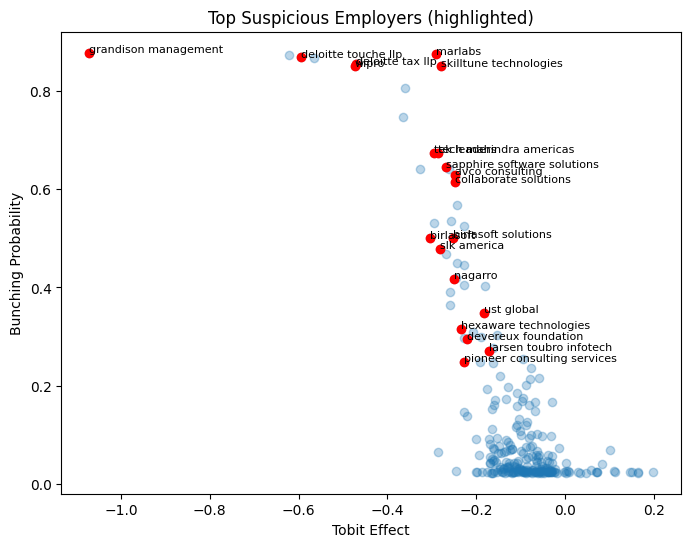

In [ ]:
combined = pd.read_csv("combined.csv")
combined = combined.set_index("EMPLOYER_NAME_CLEAN")
combined = combined.join(employer_effects.rename("tobit_effect"))
df = combined.copy()
df = df.dropna(subset=["tobit_effect", "low_level_prob", "theta_mean"])
print("Correlation (Tobit vs low-level):",
      df["tobit_effect"].corr(df["low_level_prob"]))

print("Correlation (Tobit vs bunching):",
      df["tobit_effect"].corr(df["theta_mean"]))

plt.figure(figsize=(8,6))

plt.scatter(
    df["tobit_effect"],
    df["low_level_prob"],
    alpha=0.6
)

# regression line
coef = np.polyfit(df["tobit_effect"], df["low_level_prob"], 1)
x = np.linspace(df["tobit_effect"].min(), df["tobit_effect"].max(), 100)
y = coef[0]*x + coef[1]

plt.plot(x, y)

plt.xlabel("Tobit Employer Effect (latent wage)")
plt.ylabel("Low-Level Probability")
plt.title("Tobit vs Wage Level Behavior")

plt.show()

plt.figure(figsize=(8,6))

plt.scatter(
    df["tobit_effect"],
    df["theta_mean"],
    alpha=0.6
)

coef = np.polyfit(df["tobit_effect"], df["theta_mean"], 1)
x = np.linspace(df["tobit_effect"].min(), df["tobit_effect"].max(), 100)
y = coef[0]*x + coef[1]

plt.plot(x, y)

plt.xlabel("Tobit Employer Effect (latent wage)")
plt.ylabel("Bunching Probability")
plt.title("Tobit vs Bunching")

plt.show()

X = sm.add_constant(df["tobit_effect"])
model1 = sm.OLS(df["low_level_prob"], X).fit()
print(model1.summary())
X = sm.add_constant(df["tobit_effect"])
model2 = sm.OLS(df["theta_mean"], X).fit()
print(model2.summary())

df["rank_tobit"] = (-df["tobit_effect"]).rank(pct=True)
df["rank_low"] = df["low_level_prob"].rank(pct=True)
df["rank_bunch"] = df["theta_mean"].rank(pct=True)

df["joint_score"] = (
    df["rank_tobit"] +
    df["rank_low"] +
    df["rank_bunch"]
) / 3

top_suspicious = df.sort_values("joint_score", ascending=False).head(20)

print(top_suspicious[[
    "tobit_effect",
    "low_level_prob",
    "theta_mean",
    "joint_score"
]])

plt.figure(figsize=(8,6))

plt.scatter(df["tobit_effect"], df["theta_mean"], alpha=0.3)
plt.scatter(
    top_suspicious["tobit_effect"],
    top_suspicious["theta_mean"],
    color="red"
)

for i, txt in enumerate(top_suspicious.index):
    plt.text(
        top_suspicious["tobit_effect"].iloc[i],
        top_suspicious["theta_mean"].iloc[i],
        txt,
        fontsize=8
    )

plt.xlabel("Tobit Effect")
plt.ylabel("Bunching Probability")
plt.title("Top Suspicious Employers (highlighted)")

plt.show()

(array([1.00000e+00, 2.00000e+00, 3.00000e+00, 0.00000e+00, 8.00000e+00,
        2.40000e+01, 5.00000e+00, 2.00000e+01, 8.07404e+05, 2.19529e+05,
        2.45286e+05, 2.42839e+05, 2.18981e+05, 1.93534e+05, 1.59962e+05,
        1.34759e+05, 1.10672e+05, 8.99790e+04, 7.43860e+04, 6.29980e+04]),
 array([-0.28449301, -0.24999525, -0.21549748, -0.18099972, -0.14650196,
        -0.1120042 , -0.07750643, -0.04300867, -0.00851091,  0.02598686,
         0.06048462,  0.09498238,  0.12948015,  0.16397791,  0.19847567,
         0.23297344,  0.2674712 ,  0.30196896,  0.33646672,  0.37096449,
         0.40546225]),
 <BarContainer object of 20 artists>)

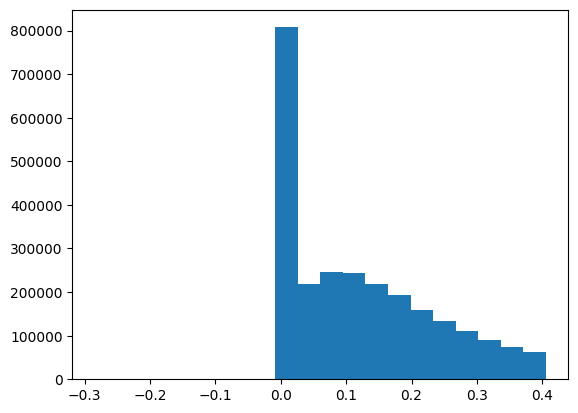

In [5]:
#get and plot log wage ratio 

plt.hist(np.log(df['wage_ratio']),bins = 20)